In [5]:
import cv2
import os
import numpy as np

In [6]:
perfect_folder = "PCB_USED"
defect_main_folder = "images"
output_folder = "subtraction_output"

os.makedirs(output_folder, exist_ok=True)

for class_name in os.listdir(defect_main_folder):

    class_path = os.path.join(defect_main_folder, class_name)

    if os.path.isdir(class_path):

        print("Processing class:", class_name)

        save_class_path = os.path.join(output_folder, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):

            defect_path = os.path.join(class_path, img_name)

            # 👇 Extract first number (01, 04, 05...)
            perfect_id = img_name.split("_")[0]

            perfect_path = os.path.join(perfect_folder, perfect_id + ".JPG")

            if not os.path.exists(perfect_path):
                print("Perfect image not found for:", img_name)
                continue

            defect_img = cv2.imread(defect_path)
            perfect_img = cv2.imread(perfect_path)

            defect_gray = cv2.cvtColor(defect_img, cv2.COLOR_BGR2GRAY)
            perfect_gray = cv2.cvtColor(perfect_img, cv2.COLOR_BGR2GRAY)

            perfect_resized = cv2.resize(perfect_gray,
                                         (defect_gray.shape[1], defect_gray.shape[0]))

            subtraction = cv2.absdiff(perfect_resized, defect_gray)

            _, thresh = cv2.threshold(subtraction, 30, 255, cv2.THRESH_BINARY)

            save_path = os.path.join(save_class_path, img_name)
            cv2.imwrite(save_path, thresh)

print("Image subtraction completed successfully!")

Processing class: Missing_hole
Processing class: Mouse_bite
Processing class: Open_circuit
Processing class: Short
Processing class: Spur
Processing class: Spurious_copper
Image subtraction completed successfully!


In [3]:


input_folder = "subtraction_output"
roi_output_folder = "roi_output"

os.makedirs(roi_output_folder, exist_ok=True)

for class_name in os.listdir(input_folder):

    class_path = os.path.join(input_folder, class_name)

    if os.path.isdir(class_path):

        print("Extracting ROI for class:", class_name)

        save_class_path = os.path.join(roi_output_folder, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):

            # Process only image files
            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            # 🔥 Skip if image not loaded
            if img is None:
                print("Skipping unreadable file:", img_name)
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

            contours, _ = cv2.findContours(thresh,
                                           cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)

            if len(contours) == 0:
                continue

            largest_contour = max(contours, key=cv2.contourArea)

            if cv2.contourArea(largest_contour) < 50:
                continue

            x, y, w, h = cv2.boundingRect(largest_contour)

            roi = img[y:y+h, x:x+w]

            save_path = os.path.join(save_class_path, img_name)
            cv2.imwrite(save_path, roi)

print("ROI extraction completed successfully!")

SyntaxError: invalid syntax (4224956608.py, line 10)

In [7]:
roi_folder = "roi_output"
defect_output_folder = "detected_defects"

os.makedirs(defect_output_folder, exist_ok=True)

for class_name in os.listdir(roi_folder):

    class_path = os.path.join(roi_folder, class_name)

    if os.path.isdir(class_path):

        print("Detecting defects in class:", class_name)

        save_class_path = os.path.join(defect_output_folder, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):

            if not img_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Highlight white defect areas
            _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

            # Remove small noise
            kernel = np.ones((3,3), np.uint8)
            thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

            contours, _ = cv2.findContours(thresh,
                                           cv2.RETR_EXTERNAL,
                                           cv2.CHAIN_APPROX_SIMPLE)

            for cnt in contours:

                if cv2.contourArea(cnt) < 40:
                    continue

                x, y, w, h = cv2.boundingRect(cnt)

                defect = img[y:y+h, x:x+w]

                save_path = os.path.join(save_class_path,
                                         "defect_" + img_name)

                cv2.imwrite(save_path, defect)

print("Defect extraction completed!")

Detecting defects in class: Missing_hole
Detecting defects in class: Mouse_bite
Detecting defects in class: Open_circuit
Detecting defects in class: Short
Detecting defects in class: Spur
Detecting defects in class: Spurious_copper
Defect extraction completed!


In [8]:
input_folder = "detected_defects"
output_folder = "preprocessed_images"

os.makedirs(output_folder, exist_ok=True)

IMG_SIZE = 224

for class_name in os.listdir(input_folder):

    class_path = os.path.join(input_folder, class_name)

    if os.path.isdir(class_path):

        print("Preprocessing class:", class_name)

        save_class_path = os.path.join(output_folder, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):

            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            #  Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            #  Convert to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            #  Noise removal
            blur = cv2.GaussianBlur(gray, (5,5), 0)

            # Contrast enhancement
            equalized = cv2.equalizeHist(blur)

            #  Normalize 
            normalized = equalized / 255.0
            normalized = (normalized * 255).astype(np.uint8)

            save_path = os.path.join(save_class_path, img_name)
            cv2.imwrite(save_path, normalized)

print("Preprocessing completed successfully!")

Preprocessing class: Missing_hole
Preprocessing class: Mouse_bite
Preprocessing class: Open_circuit
Preprocessing class: Short
Preprocessing class: Spur
Preprocessing class: Spurious_copper
Preprocessing completed successfully!


In [9]:
input_folder = "preprocessed_images"
output_folder = "augmented_images"

os.makedirs(output_folder, exist_ok=True)

for class_name in os.listdir(input_folder):

    class_path = os.path.join(input_folder, class_name)

    if os.path.isdir(class_path):

        print("Augmenting class:", class_name)

        save_class_path = os.path.join(output_folder, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):

            if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            base_name = img_name.split('.')[0]

            h, w = img.shape[:2]

            #  Rotation (15 degrees)
            matrix = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
            rotated = cv2.warpAffine(img, matrix, (w, h))
            cv2.imwrite(os.path.join(save_class_path, base_name+"_rot.jpg"), rotated)

            #  Horizontal Flip
            flipped = cv2.flip(img, 1)
            cv2.imwrite(os.path.join(save_class_path, base_name+"_flip.jpg"), flipped)

            #  Zoom (crop center and resize)
            zoom = img[20:h-20, 20:w-20]
            zoom = cv2.resize(zoom, (w, h))
            cv2.imwrite(os.path.join(save_class_path, base_name+"_zoom.jpg"), zoom)

print("Augmentation completed successfully!")

Augmenting class: .ipynb_checkpoints
Augmenting class: Missing_hole
Augmenting class: Mouse_bite
Augmenting class: Open_circuit
Augmenting class: Short
Augmenting class: Spur
Augmenting class: Spurious_copper
Augmentation completed successfully!


Found 1563 images belonging to 6 classes.
Found 389 images belonging to 6 classes.
Classes found: {'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}
Number of classes: 6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

...

49/49 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3269 - loss: 1.8204 - val_accuracy: 0.4679 - val_loss: 1.4331 - learning_rate: 1.0000e-04
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.5286 - loss: 1.3096
Epoch 2: val_accuracy improved from 0.46787 to 0.48329, saving model to best_pcb_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5291 - loss: 1.2964 - val_accuracy: 0.4833 - val_loss: 1.3483 - learning_rate: 1.0000e-04
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.5684 - loss: 1.1868
Epoch 3: val_accuracy did not improve from 0.48329
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5797 - loss: 1.1243 - val_accuracy: 0.4833 - val_loss: 1.3368 - learning_rate: 1.0000e-04
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 886ms/step - accuracy: 0.6021 - loss: 1.0615
Epoch 4: val_accuracy did not improve from 0.48329
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.6123 - loss: 1.0444 - val_accuracy: 0.4807 - val_loss: 1.2935 - learning_rate: 1.0000e-04
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.6566 - loss: 0.9332
Epoch 5: val_accuracy improved from 0.48329 to 0.51157, saving model to best_pcb_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6558 - loss: 0.9360 - val_accuracy: 0.5116 - val_loss: 1.2822 - learning_rate: 1.0000e-04
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.6790 - loss: 0.8888
Epoch 6: val_accuracy improved from 0.51157 to 0.51414, saving model to best_pcb_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6660 - loss: 0.9030 - val_accuracy: 0.5141 - val_loss: 1.2570 - learning_rate: 1.0000e-04
Epoch 7/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.6651 - loss: 0.8565
Epoch 7: val_accuracy improved from 0.51414 to 0.51671, saving model to best_pcb_model.h5


49/49 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6679 - loss: 0.8707 - val_accuracy: 0.5167 - val_loss: 1.2909 - learning_rate: 1.0000e-04
Epoch 8/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.7324 - loss: 0.7660
Epoch 8: val_accuracy did not improve from 0.51671
49/49 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6961 - loss: 0.8103 - val_accuracy: 0.5039 - val_loss: 1.2848 - learning_rate: 1.0000e-04
Epoch 9/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 875ms/step - accuracy: 0.6979 - loss: 0.7964
Epoch 9: val_accuracy did not improve from 0.51671

Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6903 - loss: 0.7867 - val_accuracy: 0.5090 - val_loss: 1.2797 - learning_rate: 1.0000e-04
Epoch 10/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.7141 - loss: 0.7756
Epoch 10: val_accuracy did not improve from 0.51671
49/49 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7147 - loss: 0.7719 - val_ac

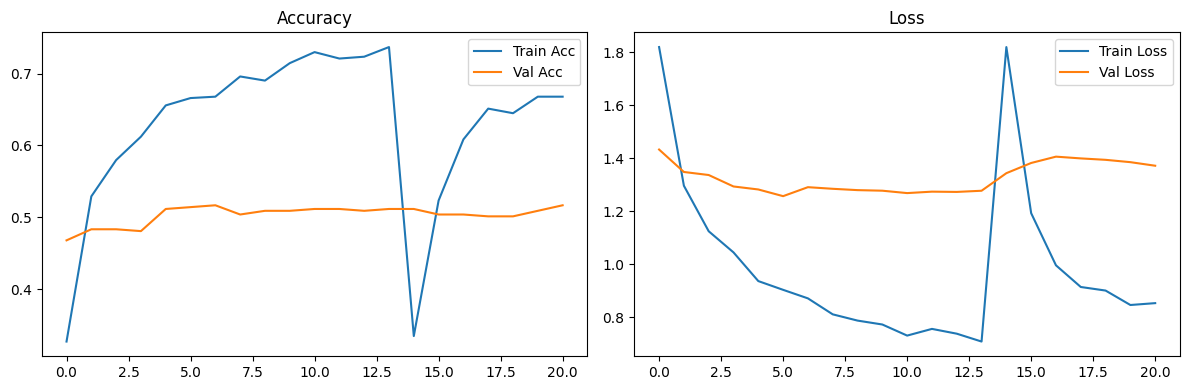


✅ Model saved as pcb_defect_classifier_final.h5


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# ─── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR    = "augmented_images"
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 0.0001

# ─── DATA GENERATORS ──────────────────────────────────────────────────────────
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    color_mode='rgb'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    color_mode='rgb'
)

NUM_CLASSES = len(train_gen.class_indices)
print("Classes found:", train_gen.class_indices)
print("Number of classes:", NUM_CLASSES)

# ─── MODEL (Transfer Learning) ────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ─── CALLBACKS ────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint("best_pcb_model.h5", save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(patience=7, monitor='val_accuracy', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# ─── PHASE 1: Train top layers ─────────────────────────────────────────────────
print("\n🔥 Phase 1: Training top layers...")
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

# ─── PHASE 2: Fine-tune last 30 layers ────────────────────────────────────────
print("\n🔥 Phase 2: Fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ─── EVALUATION ───────────────────────────────────────────────────────────────
val_gen.reset()
preds = model.predict(val_gen)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes
labels = list(train_gen.class_indices.keys())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

# ─── PLOT TRAINING CURVES ─────────────────────────────────────────────────────
def plot_history(h1, h2):
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    vloss= h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val, label='Val Acc')
    plt.title('Accuracy'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(vloss, label='Val Loss')
    plt.title('Loss'); plt.legend()

    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

plot_history(history1, history2)

# ─── SAVE FINAL MODEL ─────────────────────────────────────────────────────────
model.save("pcb_defect_classifier_final.h5")
print("\n✅ Model saved as pcb_defect_classifier_final.h5")

In [10]:
loss, accuracy = model.evaluate(val_data)
print("Model Loss:", loss)
print("Model Accuracy:", accuracy * 100, "%")

NameError: name 'val_data' is not defined

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "dataset/train"
test_dir = "dataset/test"

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

# Save model
model.save("pcb_defect_model.h5")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'dataset/train'

In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'Annotations', 'augmented_images', 'detected_defects', 'images', 'implementation.ipynb', 'PCB_USED', 'preprocessed_images', 'roi_output', 'rotate.py', 'rotation', 'subtracted_images', 'subtraction_output']


In [2]:
import shutil
shutil.rmtree("augmented_images/.ipynb_checkpoints", ignore_errors=True)

In [7]:
import os

for root, dirs, files in os.walk("augmented_images"):
    for d in dirs:
        if d == ".ipynb_checkpoints":
            print("Found at:", os.path.join(root, d))

Found at: augmented_images\Missing_hole\.ipynb_checkpoints
Found at: augmented_images\Mouse_bite\.ipynb_checkpoints


In [8]:
import shutil, os

for root, dirs, files in os.walk("augmented_images", topdown=False):
    for d in dirs:
        if d == ".ipynb_checkpoints":
            path = os.path.join(root, d)
            shutil.rmtree(path)
            print(f"✅ Deleted: {path}")

print("🧹 Cleanup done!")

✅ Deleted: augmented_images\Missing_hole\.ipynb_checkpoints
✅ Deleted: augmented_images\Mouse_bite\.ipynb_checkpoints
🧹 Cleanup done!


In [11]:
import pickle

# ─── SAVE MODEL METADATA AS PKL ───────────────────────────────────────────────
model_metadata = {
    "class_indices": train_gen.class_indices,
    "class_names": list(train_gen.class_indices.keys()),
    "img_size": IMG_SIZE,
    "num_classes": NUM_CLASSES
}

with open("pcb_model_metadata.pkl", "wb") as f:
    pickle.dump(model_metadata, f)

print("✅ PKL file saved as pcb_model_metadata.pkl")
print("📦 Contents:", model_metadata)

✅ PKL file saved as pcb_model_metadata.pkl
📦 Contents: {'class_indices': {'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}, 'class_names': ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper'], 'img_size': 224, 'num_classes': 6}
